In [17]:
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

# load your .env file
load_dotenv("../backend/.env")   # adjust path if needed

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:5432/{os.getenv('DB_NAME')}"
)

In [18]:
import pandas as pd
df_funnel = pd.read_sql("""
    with funnel as(
	select count(distinct case when event_type='signup_completed' then user_id end) as signup,
	count(distinct case when event_type='email_verified' then user_id end) as email,
	count(distinct case when event_type='onboarding_completed' then user_id end) as onboarding,
	count(distinct case when event_type='risk_quiz_completed' then user_id end) as risk_quiz,
	count(distinct case when event_type='kyc_completed' then user_id end) as kyc,
	count(distinct case when event_type='deposit_completed' then user_id end) as deposit,
	count(distinct case when event_type='portfolio_created' then user_id end) as portfolio
	from events
)
select 
	250000 as total_users,
	signup, round((signup*100/250000),1) as signup_pct,
	email, round((email*100/signup),1) as email_of_signup,
	onboarding,    ROUND(onboarding * 100.0 / email, 1)AS onboard_of_email,
    risk_quiz,     ROUND(risk_quiz * 100.0 / onboarding,1) AS quiz_of_onboard,
    kyc,           ROUND(kyc * 100.0 / risk_quiz, 1)   AS kyc_of_quiz,
    deposit,       ROUND(deposit * 100.0 / kyc, 1)     AS deposit_of_kyc,
    portfolio,     ROUND(portfolio * 100.0 / deposit, 1) AS portfolio_of_deposit
from funnel;
""", engine)

In [19]:
df_funnel

,total_users,signup,signup_pct,email,email_of_signup,onboarding,onboard_of_email,risk_quiz,quiz_of_onboard,kyc,kyc_of_quiz,deposit,deposit_of_kyc,portfolio,portfolio_of_deposit
0,250000,175204,70.0,149089,85.0,134176,90.0,55591,41.4,49679,89.4,32055,64.5,30377,94.8


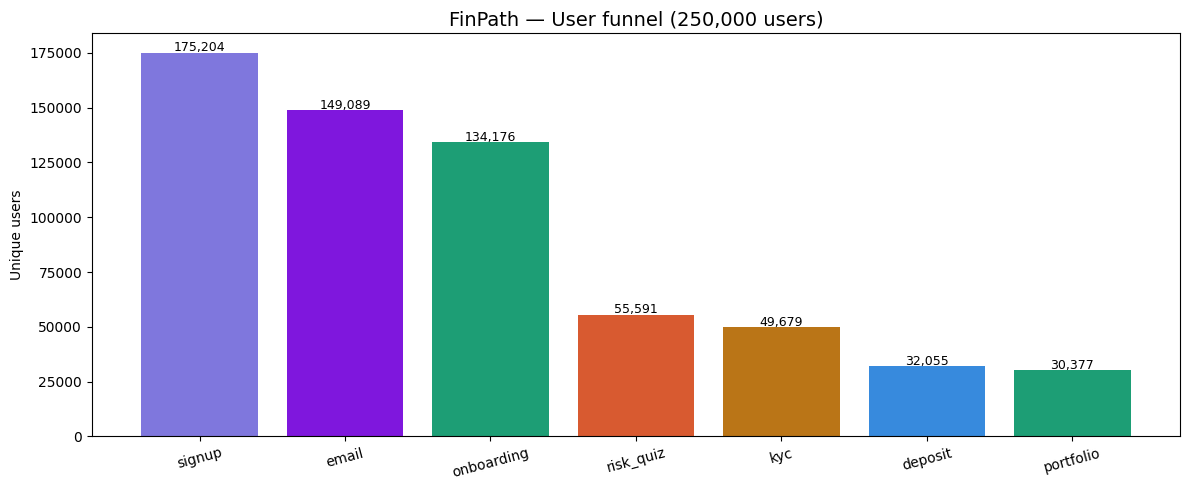

In [20]:
import matplotlib.pyplot as plt
stages = ['signup', 'email', 'onboarding', 'risk_quiz', 'kyc', 'deposit', 'portfolio']
values = [df_funnel[s].values[0] for s in stages]

plt.figure(figsize=(12, 5))
bars = plt.bar(stages, values, color=['#7F77DD','#7F17DD','#1D9E75',
                                       '#D85A30','#BA7517','#378ADD','#1D9E75'])
plt.title('FinPath — User funnel (250,000 users)', fontsize=14)
plt.ylabel('Unique users')
plt.xticks(rotation=15)

# add value labels on bars
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{int(val):,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('funnel_chart.png', dpi=150)
plt.show()

In [23]:
dropoff_query = """
WITH stage_events AS (
    SELECT
        user_id,
        MAX(CASE WHEN event_type = 'signup_completed'     THEN 1 ELSE 0 END) AS did_signup,
        MAX(CASE WHEN event_type = 'email_verified'       THEN 1 ELSE 0 END) AS did_email,
        MAX(CASE WHEN event_type = 'onboarding_completed' THEN 1 ELSE 0 END) AS did_onboard,
        MAX(CASE WHEN event_type = 'risk_quiz_completed'  THEN 1 ELSE 0 END) AS did_quiz,
        MAX(CASE WHEN event_type = 'kyc_completed'        THEN 1 ELSE 0 END) AS did_kyc,
        MAX(CASE WHEN event_type = 'deposit_completed'    THEN 1 ELSE 0 END) AS did_deposit,
        MAX(CASE WHEN event_type = 'portfolio_created'    THEN 1 ELSE 0 END) AS did_portfolio
    FROM events
    GROUP BY user_id
),
totals AS (
    SELECT
        SUM(did_signup)   AS s1,
        SUM(did_email)    AS s2,
        SUM(did_onboard)  AS s3,
        SUM(did_quiz)     AS s4,
        SUM(did_kyc)      AS s5,
        SUM(did_deposit)  AS s6,
        SUM(did_portfolio)AS s7
    FROM stage_events
)
SELECT stage, started, finished,
       started - finished AS dropped_off,
       ROUND((1 - finished::numeric / started) * 100, 1) AS dropoff_pct
FROM (
    SELECT 'signup → email'      AS stage, s1 AS started, s2 AS finished FROM totals
    UNION ALL
    SELECT 'email → onboarding',            s2, s3 FROM totals
    UNION ALL
    SELECT 'onboarding → quiz',             s3, s4 FROM totals
    UNION ALL
    SELECT 'quiz → kyc',                    s4, s5 FROM totals
    UNION ALL
    SELECT 'kyc → deposit',                 s5, s6 FROM totals
    UNION ALL
    SELECT 'deposit → portfolio',           s6, s7 FROM totals
) t
ORDER BY dropoff_pct DESC
"""


In [24]:
df_dropoff=pd.read_sql(dropoff_query,engine)
df_dropoff

,stage,started,finished,dropped_off,dropoff_pct
0,onboarding → quiz,134176,55591,78585,58.6
1,kyc → deposit,49679,32055,17624,35.5
2,signup → email,175204,149089,26115,14.9
3,quiz → kyc,55591,49679,5912,10.6
4,email → onboarding,149089,134176,14913,10.0
5,deposit → portfolio,32055,30377,1678,5.2
